No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


ValueError: All-NaN slice encountered

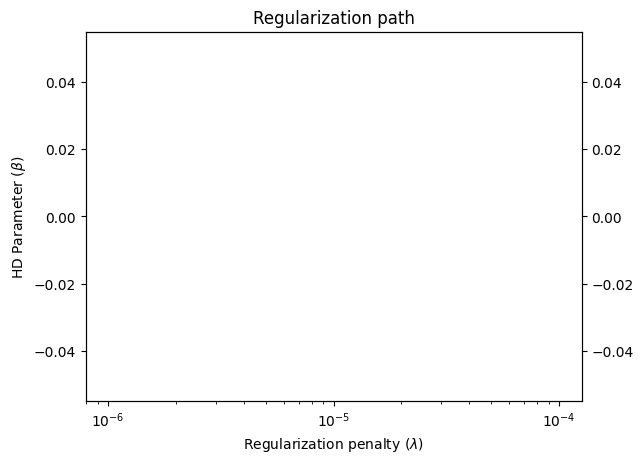

In [1]:
# Create by antoine.caillebotte@inrae.fr

import numpy as np
import pickle

import sdg4varselect.plot as sdgplt

folder = "images"


with open("res_selection.pkl", "rb") as f:
    data = pickle.load(f)

res_selection = data["res_selection"]
bic = np.array(data["bic"])
theta_reg = data["theta_reg"]
lbd_set = data["lbd_set"]
params_names = data["params_names"]
latent_variables = data["latent_variables"]
step_size = data["step_size"]

DIM_COV = data["DIM_COV"]
params_star_stack = data["params_star_stack"]

# ====================================================== #
fig, ax = sdgplt.plot_regularization_path(theta_reg, lbd_set, bic, p=DIM_COV)

z = np.poly1d(np.polyfit(lbd_set, bic, deg=4))

lbd_set_ext = np.linspace(min(lbd_set), max(lbd_set), num=1000)
bic_approx = z(lbd_set_ext)
ax[1].plot(lbd_set_ext, bic_approx, linewidth=4, color="k")

id = bic_approx.argmin()
ax[1].axvline(
    x=lbd_set_ext[id],
    color="k",
    linewidth=2,
    linestyle="--",
    label=r"$\lambda$ approx",
)
ax[1].text(
    lbd_set_ext[id],
    0.8 * bic.max() + 0.2 * bic.min(),
    rf"$\lambda$ = {lbd_set_ext[id]:.3e}",
    ha="center",
    va="center",
    rotation="vertical",
    backgroundcolor="white",
)
# ====================================================== #
# ====================================================== #

bic_argmin = np.argmin(bic)
print("regularization value selected = {lbd_set[bic_argmin]}")

# ====================================================== #

fig, ax = sdgplt.plot_params(
    x=res_selection["theta"],
    x_star=np.array(params_star_stack),
    p=DIM_COV,
    names=params_names,
    logscale=False,
)

fig.savefig(folder + "/theta.png")

fig, _ = sdgplt.plot_grad(
    x=res_selection["grad_precond"], p=DIM_COV, names=params_names
)

fig.savefig(folder + "/grad_precond.png")

fig, ax = sdgplt.plot_params_hd(res_selection["theta"], p=DIM_COV, location="right")

fig.savefig(folder + "/beta.png")

for var in latent_variables.values():
    sdgplt.plot_mcmc(var)


# ====================================================== #


fig, ax = sdgplt.plot_multi_line(
    np.array([res_selection["jac_max"]]).T, title="maximum de la jacobienne", figsize=5
)

fig.savefig(folder + "/maximum_jacobiene.png")

fig, ax = sdgplt.plot_multi_line(
    np.array([res_selection["jac_min"]]).T, title="minimum de la jacobienne", figsize=5
)

fig.savefig(folder + "/minimum_jacobiene.png")


# ====================================================== #
sdgplt.plot_multi_line(
    np.array([res_selection["likelihood"]]).T,
    title="valeur de la vraisemblance",
)

# ====================================================== #
det_fim = res_selection["fim_det"]

sdgplt.plot_multi_line(
    np.array([res_selection["fim_det"]]).T,
    title="déterminant de la fim",
    logscale=True,
)

# ====================================================== #

vp_fim = res_selection["fim_vp"]

fig, ax = sdgplt.ax_plot_list_of_vector(
    vp_fim,
    title="valeur propre de la fim",
    location="right",
)
fig.savefig(folder + "/valeur_propre_fim.png")


# ====================================================== #
fig, ax = sdgplt.plot_multi_line(
    np.array([vp_fim.min(axis=1)]).T,
    title="valeur propre minimal de la fim",
)

fig.savefig(folder + "/valeur_propre_minimal_fim.png")
# ====================================================== #

fig = sdgplt.figure()
step_size["jac"].plot(label="Jac step size")
step_size["fisher"].plot(label="FIM step size")
step_size["gradient"].plot(label="gradient step size")
sdgplt.plt.legend()

fig.savefig(folder + "/step_size.png")

regularization value selected = {lbd_set[bic_argmin]}


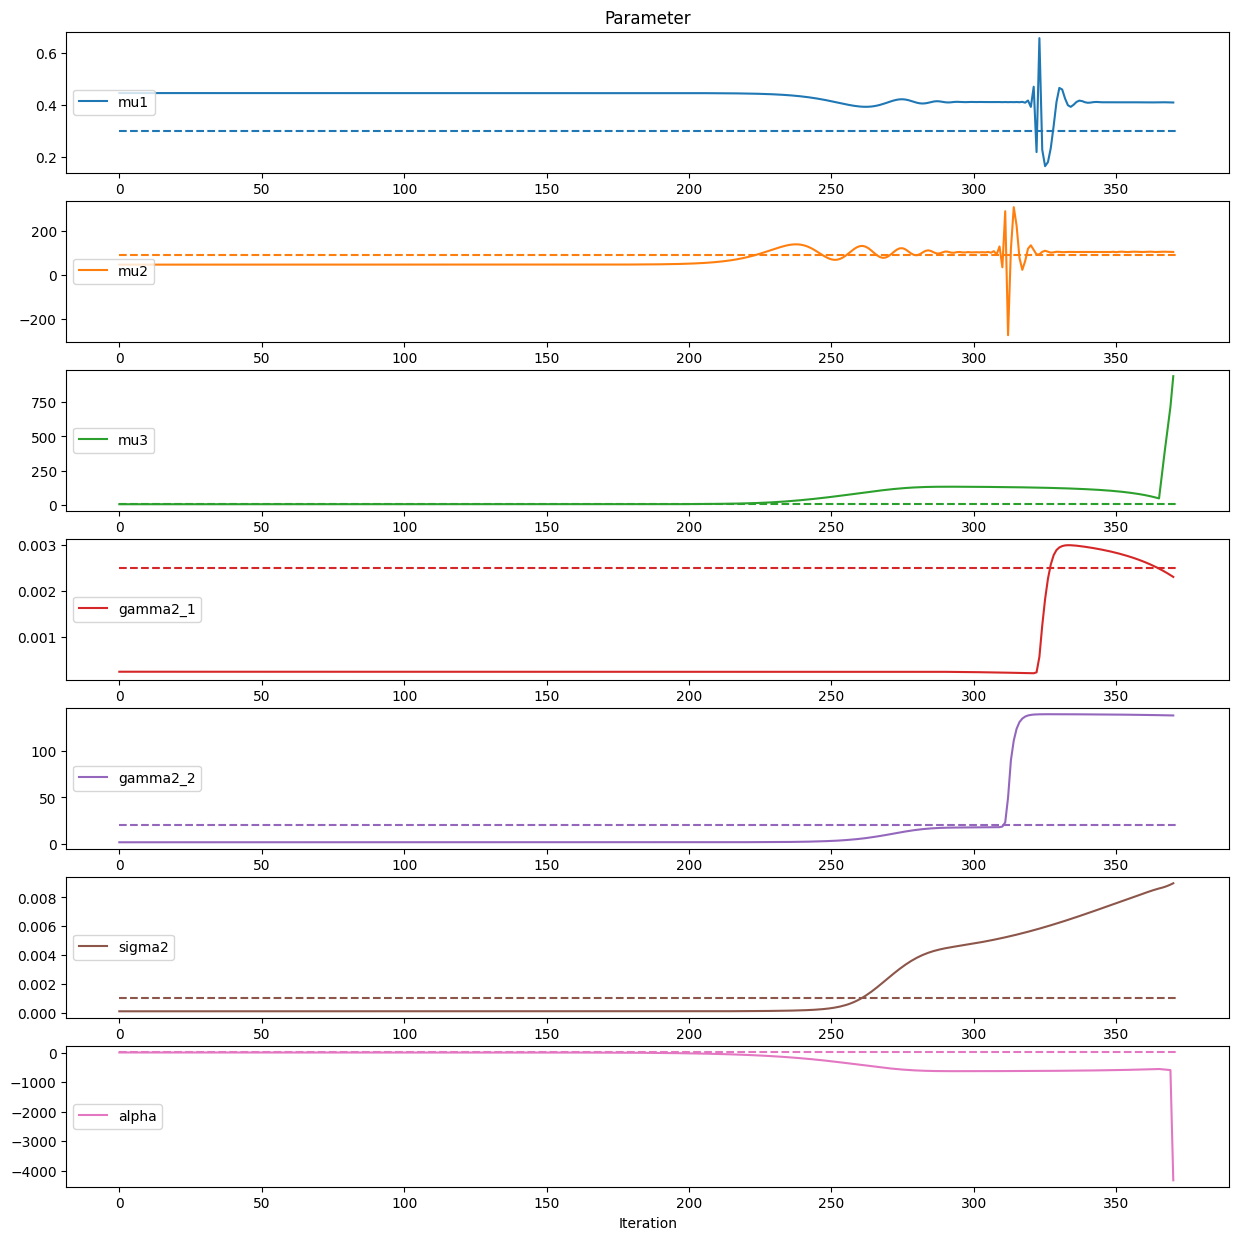

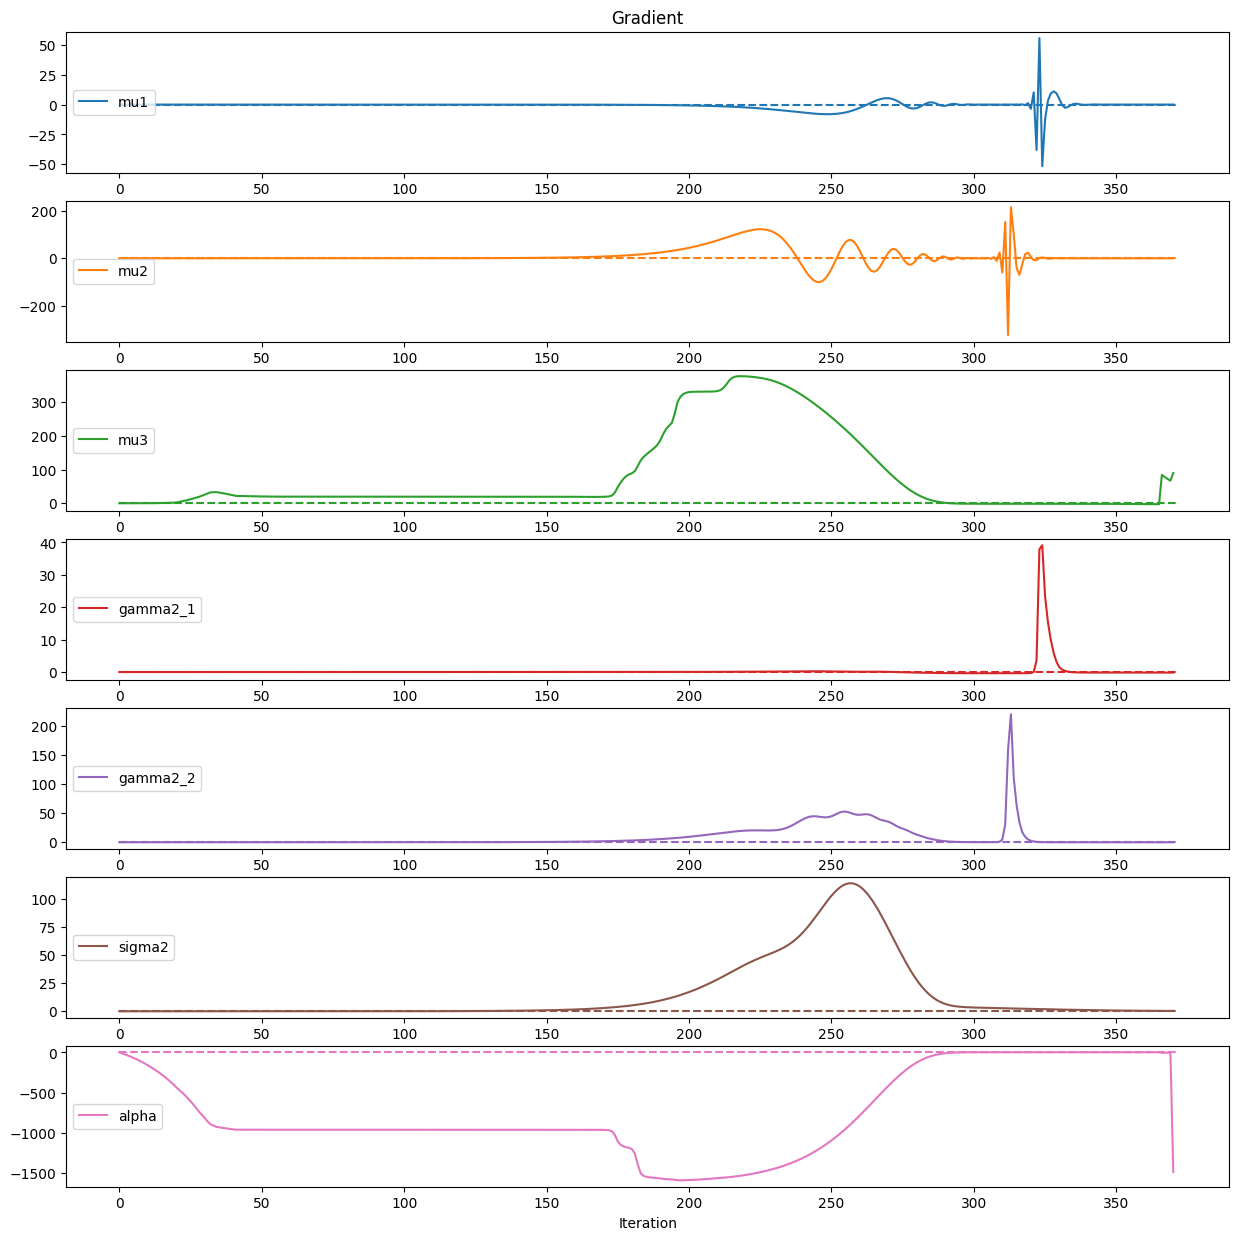

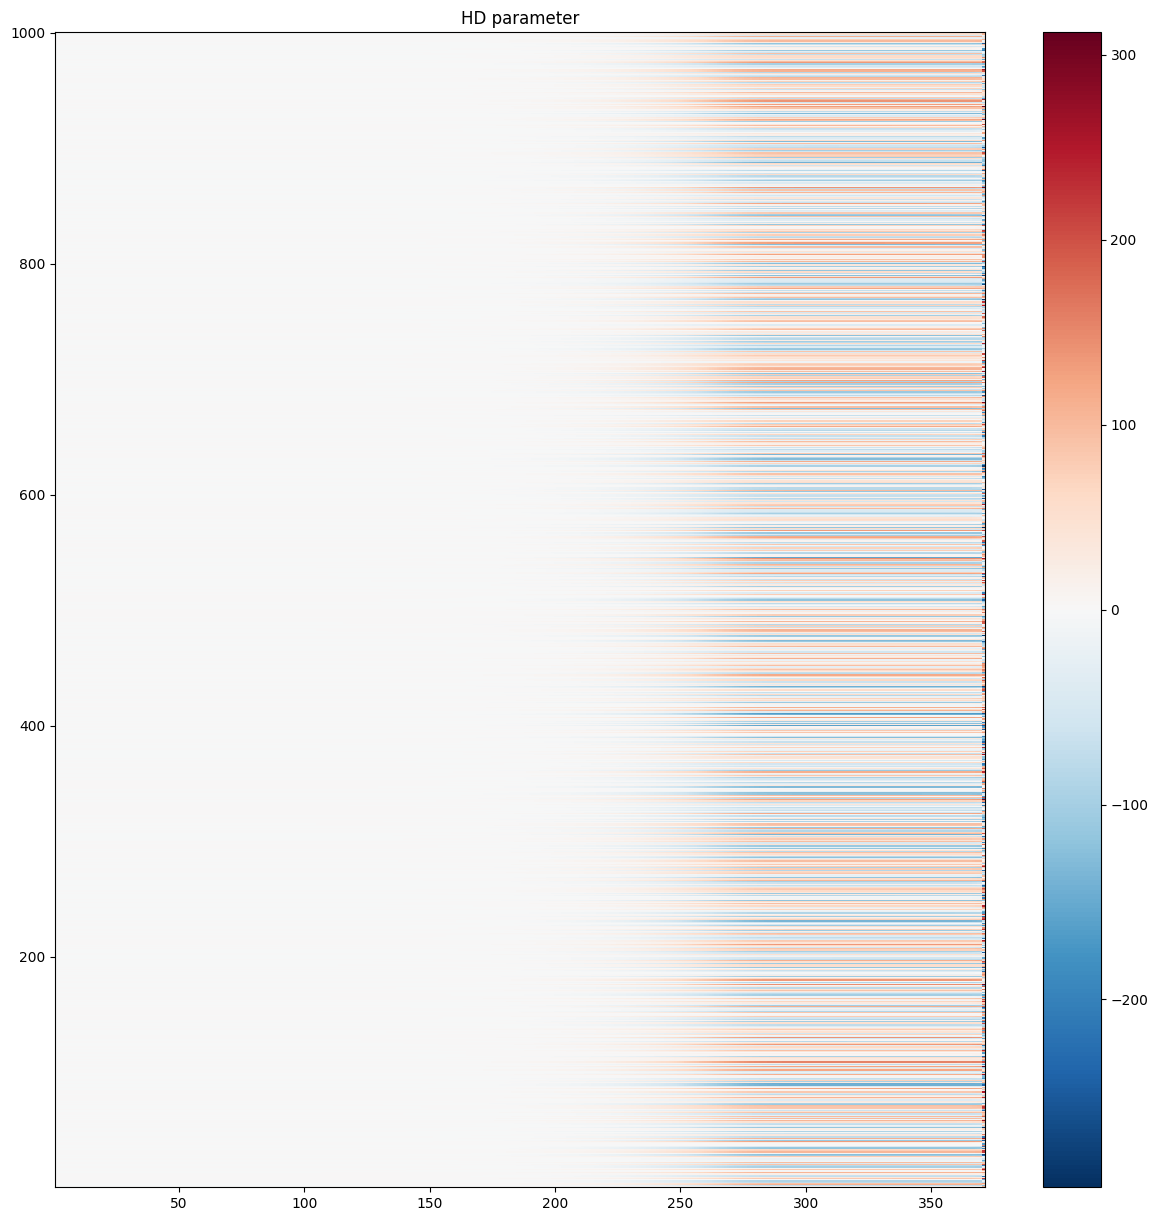

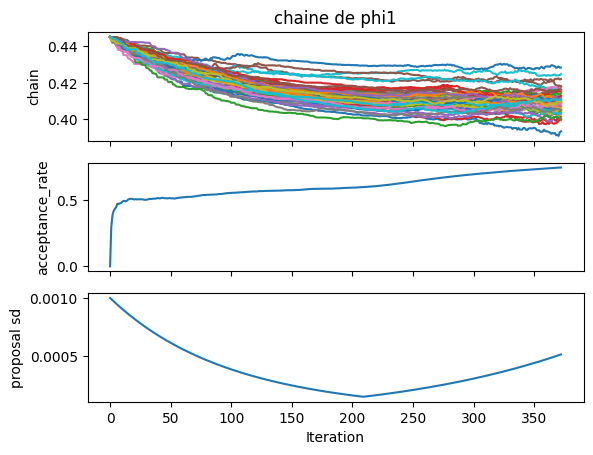

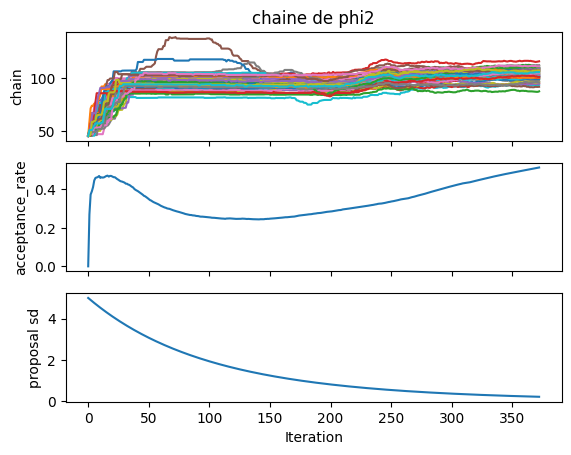

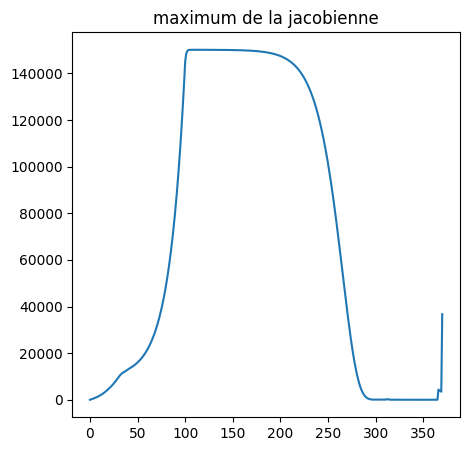

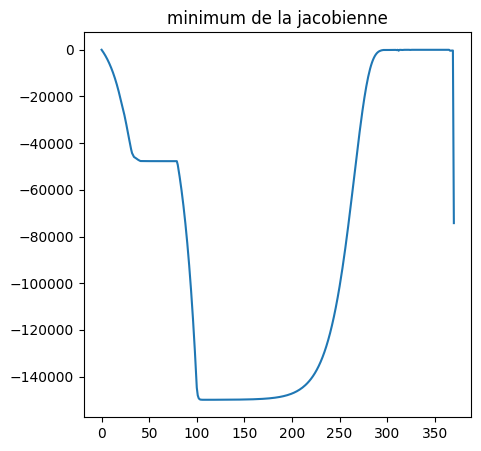

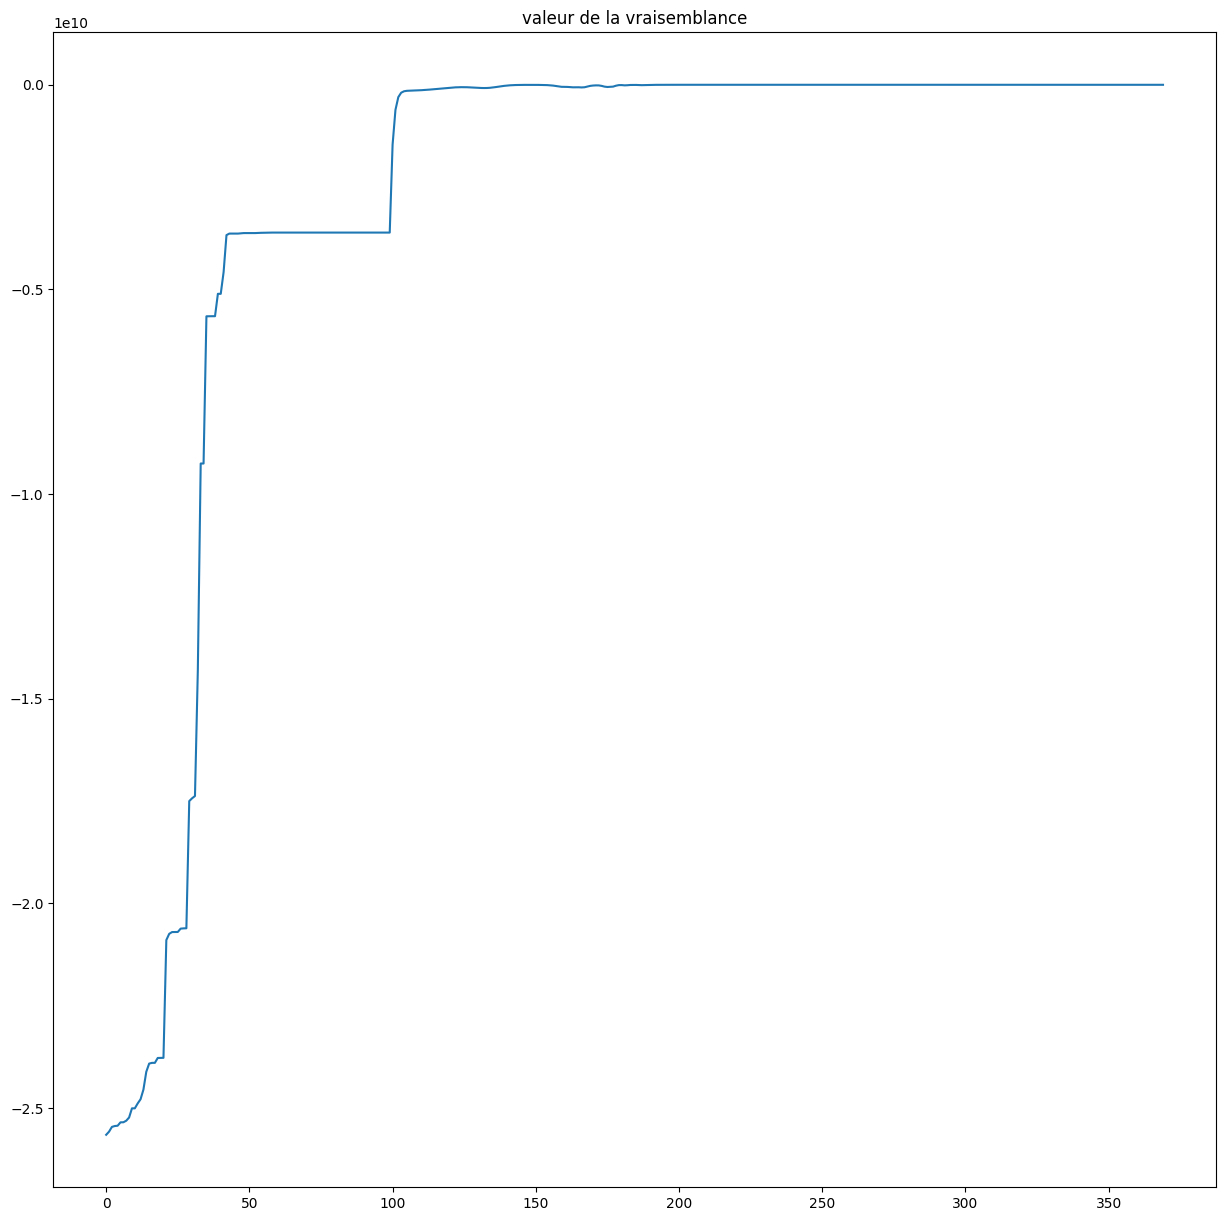

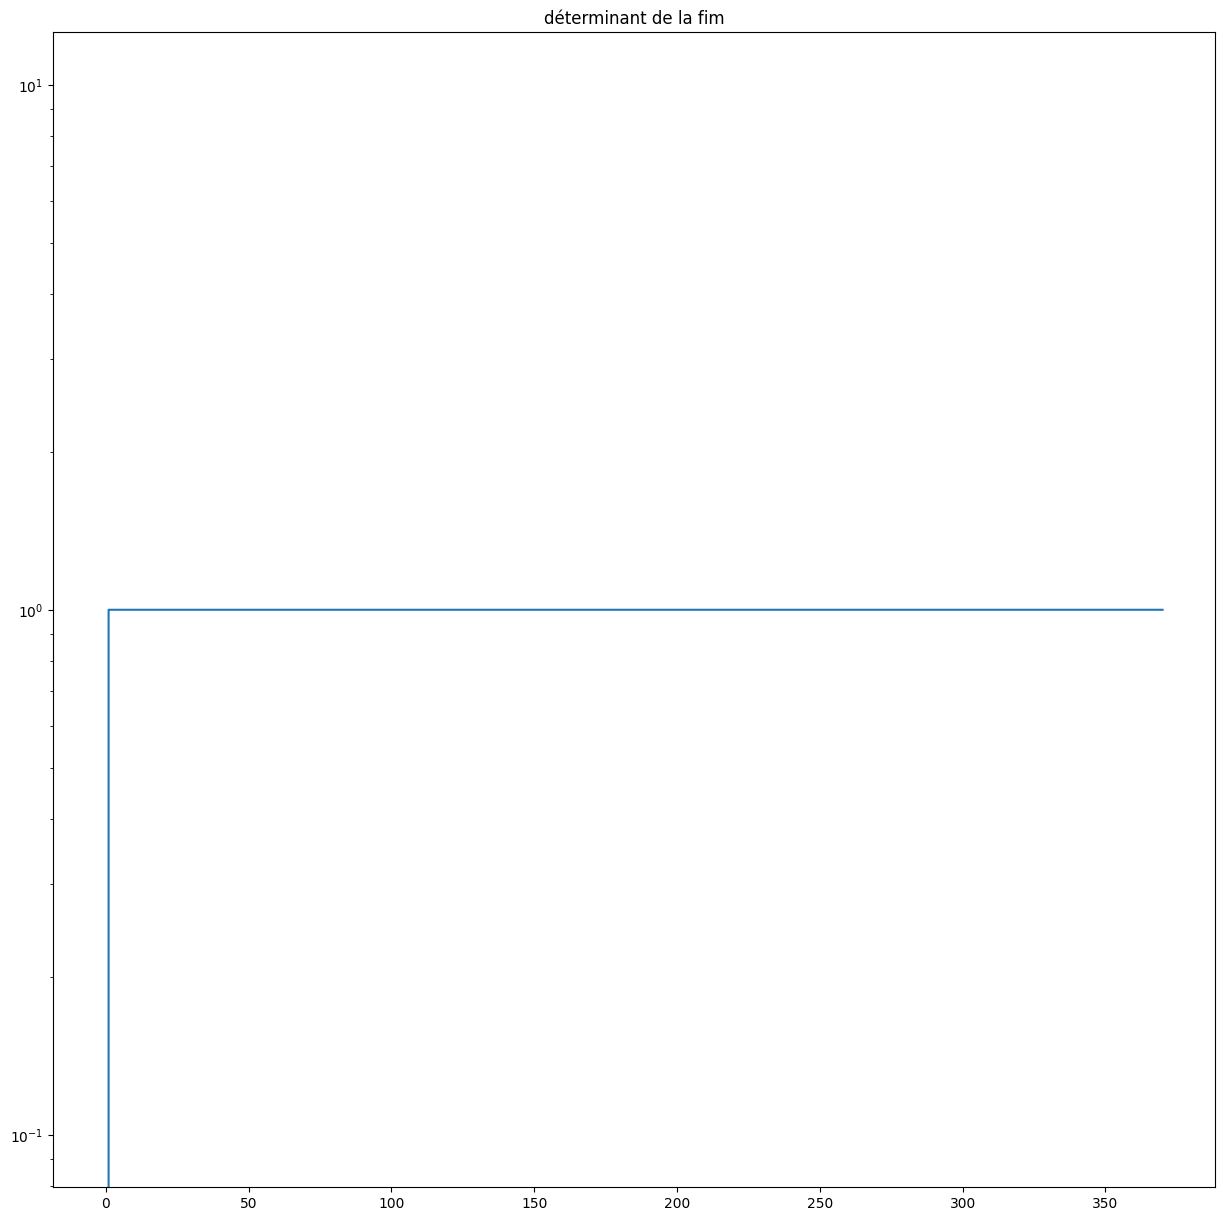

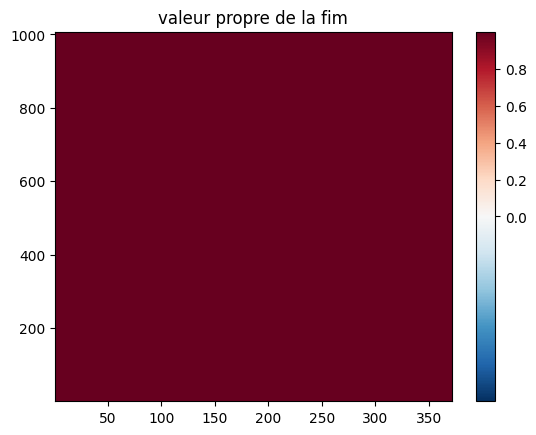

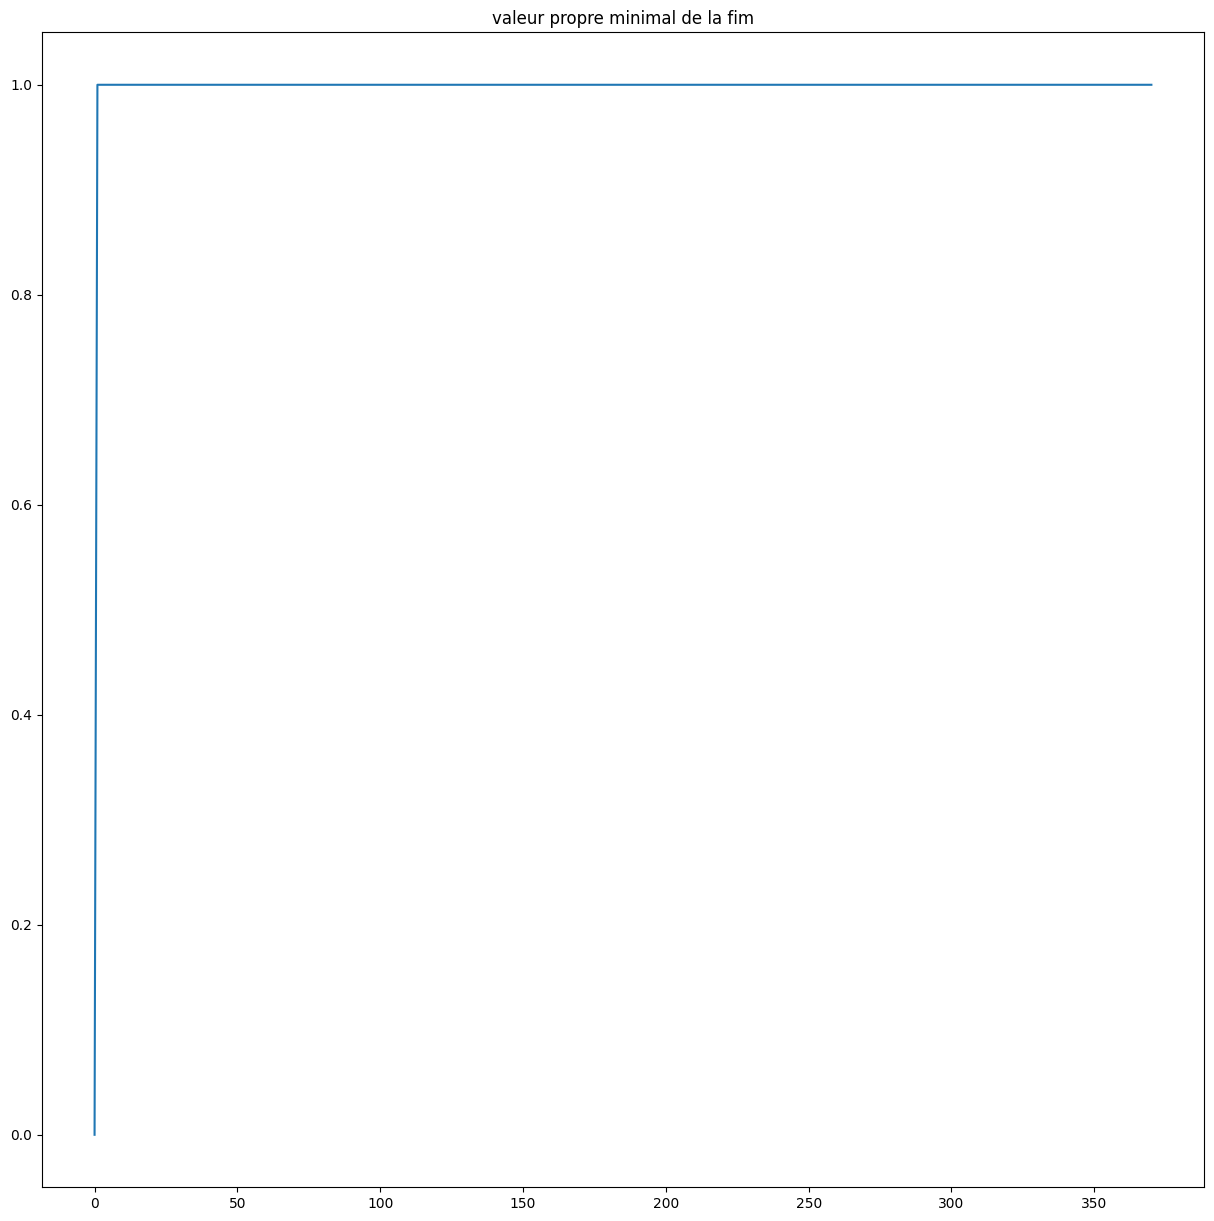

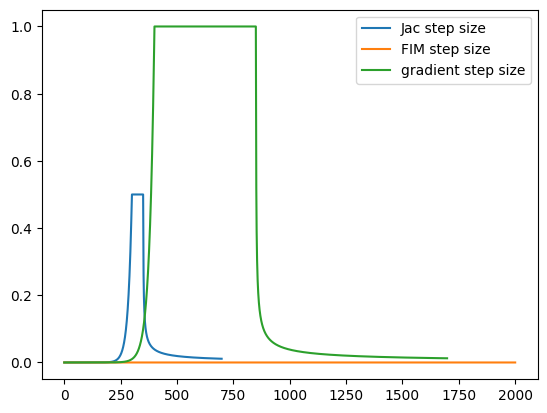

In [2]:

bic_argmin = np.argmin(bic)
print("regularization value selected = {lbd_set[bic_argmin]}")

# ====================================================== #

fig, ax = sdgplt.plot_params(
    x=res_selection["theta"],
    x_star=np.array(params_star_stack),
    p=DIM_COV,
    names=params_names,
    logscale=False,
)

fig.savefig(folder + "/theta.png")

fig, _ = sdgplt.plot_grad(
    x=res_selection["grad_precond"], p=DIM_COV, names=params_names
)

fig.savefig(folder + "/grad_precond.png")

fig, ax = sdgplt.plot_params_hd(res_selection["theta"], p=DIM_COV, location="right")

fig.savefig(folder + "/beta.png")

for var in latent_variables.values():
    sdgplt.plot_mcmc(var)


# ====================================================== #


fig, ax = sdgplt.plot_multi_line(
    np.array([res_selection["jac_max"]]).T, title="maximum de la jacobienne", figsize=5
)

fig.savefig(folder + "/maximum_jacobiene.png")

fig, ax = sdgplt.plot_multi_line(
    np.array([res_selection["jac_min"]]).T, title="minimum de la jacobienne", figsize=5
)

fig.savefig(folder + "/minimum_jacobiene.png")


# ====================================================== #
sdgplt.plot_multi_line(
    np.array([res_selection["likelihood"]]).T,
    title="valeur de la vraisemblance",
)

# ====================================================== #
det_fim = res_selection["fim_det"]

sdgplt.plot_multi_line(
    np.array([res_selection["fim_det"]]).T,
    title="déterminant de la fim",
    logscale=True,
)

# ====================================================== #

vp_fim = res_selection["fim_vp"]

fig, ax = sdgplt.ax_plot_list_of_vector(
    vp_fim,
    title="valeur propre de la fim",
    location="right",
)
fig.savefig(folder + "/valeur_propre_fim.png")


# ====================================================== #
fig, ax = sdgplt.plot_multi_line(
    np.array([vp_fim.min(axis=1)]).T,
    title="valeur propre minimal de la fim",
)

fig.savefig(folder + "/valeur_propre_minimal_fim.png")
# ====================================================== #

fig = sdgplt.figure()
step_size["jac"].plot(label="Jac step size")
step_size["fisher"].plot(label="FIM step size")
step_size["gradient"].plot(label="gradient step size")
sdgplt.plt.legend()

fig.savefig(folder + "/step_size.png")
